# E-Commerce Data Analytics Project

---

### Background
Retail stores collect massive amounts of daily transaction data, including what items were bought, when they were purchased, who bought them, and whether those items actually made money. However, raw data by itself cannot guide business decisions. Without a clear summary of performance, store management faces a major challenge: they cannot easily see where the business is thriving and where it is losing money.

### The Problem
Currently, the store lacks a clear view of its financial health and customer behavior. This makes it difficult to plan for the future, manage inventory efficiently, and maximize earnings. Specifically, the business is operating without clear answers to the following questions:

- Timing Bottlenecks: The store does not know which months drive the most revenue and profit, or which slow periods need promotional boosts.

- Product Blindspots: It is unclear which broad product categories and specific item types (sub-categories) are the top performers, and which ones are failing to generate sales or are dragging down profits.

- Customer Uncertainty: The business cannot identify which specific customer groups (segments) are their most valuable buyers versus which ones cost more to serve.

- Profit Efficiency: The store tracks overall sales volume but does not know if those high sales numbers are actually translating into meaningful profit margins.

### Project Objective
The goal of this project is to analyze the store’s transaction records to uncover clear patterns in timing, products, and customer behavior. By building a clean data analysis workflow, this project will transform raw tables into a straightforward summary of the store's best and worst-performing areas, providing the exact insights needed to cut losses and increase overall profitability.

### Technical Skills Used:

- Data Cleaning & Preparation: Using Pandas and NumPy to fix missing information, remove duplicate rows, fix messy date formats so they read correctly, and organize raw files into clean tables.

- Data Exploration & Analysis: Grouping data to calculate key business metrics—like comparing overall sales against actual profits—across different customer groups and item categories to see what drives the business.

- Data Visualization: Building clean, interactive charts (like side-by-side grouped bar charts and breakdown charts) using Plotly Express to make complex trends and numbers easy to see at a glance.

---

In [1]:
import pandas as pd
import datetime as dt
import plotly.express as px
import seaborn as sns

In [2]:
data = pd.read_csv("Sample - Superstore.csv", encoding = "latin-1") 

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
data.duplicated().any()

np.False_

---

Because,

Order Date     9994 non-null   object 

Ship Date      9994 non-null   object 

To change Order Date & Ship Date into datetime, we will do:

In [8]:
data["Order Date"] = pd.to_datetime(data['Order Date'], format = 'mixed')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], format = 'mixed') 

<code>format = 'mixed'</code> - used because we had data in multiple format like: %d-%m-%y, %d/%m%y, %m-%d-%y, etc.

In [9]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
data['Order Month'] = data['Order Date'].dt.month 
data['Order Year'] = data['Order Date'].dt.year
data['Order Day of Week'] = data['Order Date'].dt.dayofweek

In [11]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6


In [12]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Month', 'Order Year', 'Order Day of Week'],
      dtype='object')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   object        
 2   Order Date         9994 non-null   datetime64[ns]
 3   Ship Date          9994 non-null   datetime64[ns]
 4   Ship Mode          9994 non-null   object        
 5   Customer ID        9994 non-null   object        
 6   Customer Name      9994 non-null   object        
 7   Segment            9994 non-null   object        
 8   Country            9994 non-null   object        
 9   City               9994 non-null   object        
 10  State              9994 non-null   object        
 11  Postal Code        9994 non-null   int64         
 12  Region             9994 non-null   object        
 13  Product ID         9994 non-null   object        
 14  Category

---

## 1. Monthly Sales Analysis

For monthly sales analysis we need:
1. Months Name for Specific Year
2. Total sales for that month

In [14]:
sales = data.groupby(["Order Year","Order Month"])["Sales"].sum()

In [15]:
sales = sales.reset_index().sort_values("Order Year")
sales.head()

,Order Year,Order Month,Sales
0,2014,1,14236.8950
11,2014,12,69545.6205
10,2014,11,78628.7167
9,2014,10,31453.3930
7,2014,8,27909.4685


In [16]:
sales["index"] = sales["Order Month"].astype("string") + "-" + sales["Order Year"].astype("string")

In [17]:
sales.head()

,Order Year,Order Month,Sales,index
0,2014,1,14236.8950,1-2014
11,2014,12,69545.6205,12-2014
10,2014,11,78628.7167,11-2014
9,2014,10,31453.3930,10-2014
7,2014,8,27909.4685,8-2014


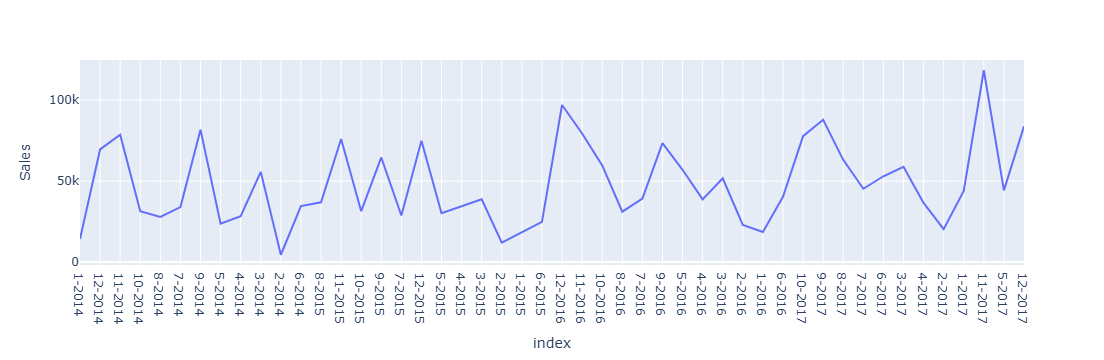

In [18]:
px.line(sales, x = "index", y = "Sales", labels = {"x":"Month", "y":"Total Sales"})

In [19]:
combined_sales = data.groupby(["Order Month"])["Sales"].sum()
combined_sales = combined_sales.reset_index()
combined_sales

,Order Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


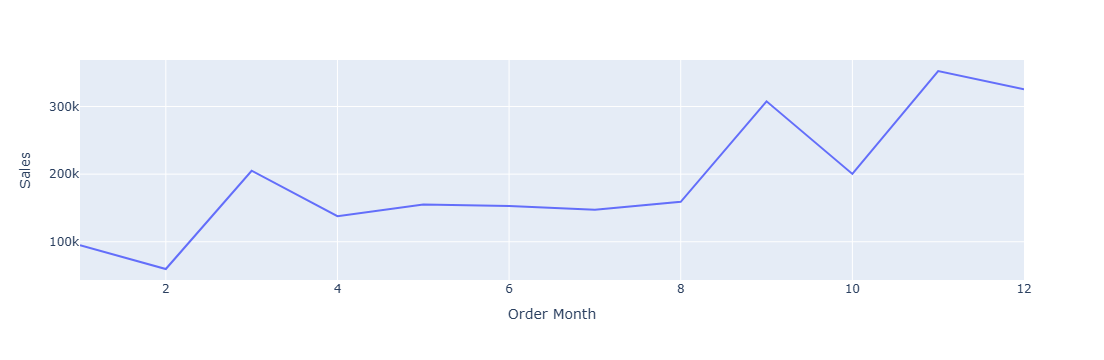

In [20]:
px.line(combined_sales, x = "Order Month", y = "Sales", labels = {"x":"Month", "y":"Combined Sales"})

#### <u> CONCLUSION:

Sales drop on Februry month and are peak from month September to December.

---

## 2. Sales Analysis by Category

In [21]:
cat_sales = data.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending = False)
cat_sales

,Category,Sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


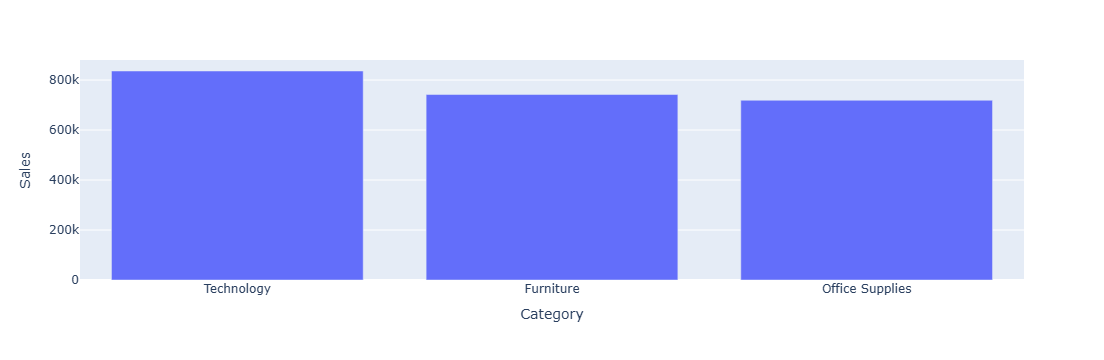

In [22]:
px.bar(cat_sales, x = "Category", y = "Sales")

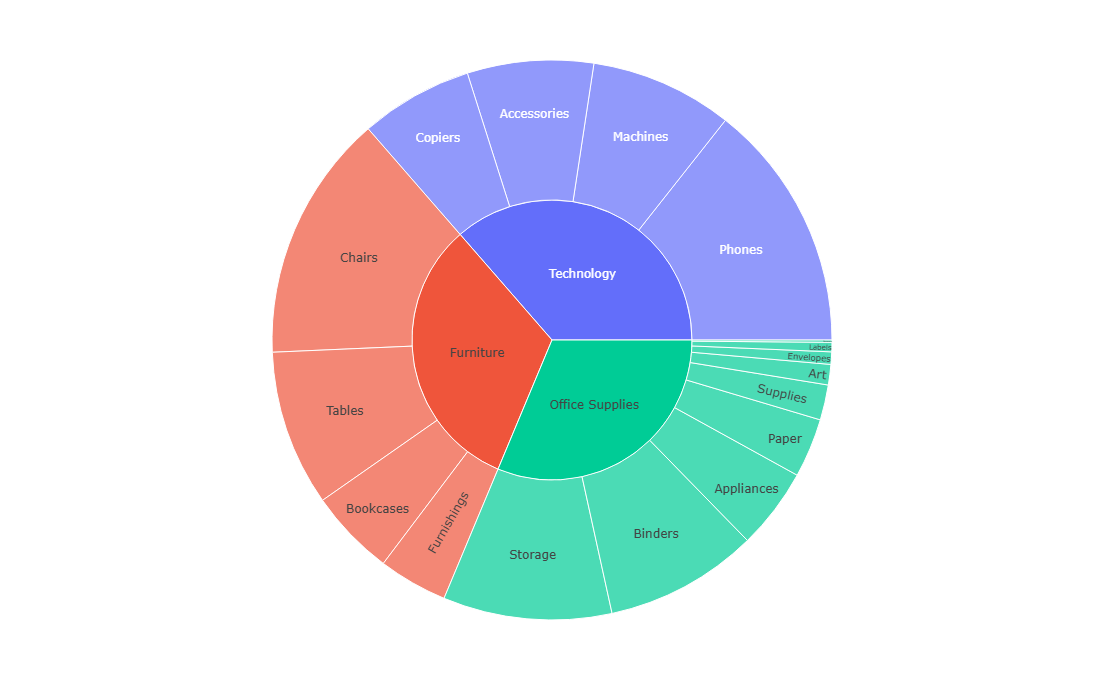

In [23]:
fig = px.sunburst(data, path = ['Category', 'Sub-Category'], values = 'Sales')
fig.update_layout(width=700, height=700)

#### <u> CONCLUSION:

Technology has maximum sales followed by furniture and office supplies.
- In Technology, Phones have maximum sales
- In Furniture, Chairs have maximum sales
- In Office Supplies, Storage have maximum sales

---

## 3. Profit Analysis by Sub-Category

In [24]:
subcat_profit = data.groupby("Sub-Category").agg({"Profit":"sum", "Sales":"sum"}).reset_index().sort_values("Sales", ascending = False)
subcat_profit

,Sub-Category,Profit,Sales
13,Phones,44515.7306,330007.0540
5,Chairs,26590.1663,328449.1030
14,Storage,21278.8264,223843.6080
16,Tables,-17725.4811,206965.5320
3,Binders,30221.7633,203412.7330
11,Machines,3384.7569,189238.6310
0,Accessories,41936.6357,167380.3180
6,Copiers,55617.8249,149528.0300
4,Bookcases,-3472.5560,114879.9963
1,Appliances,18138.0054,107532.1610


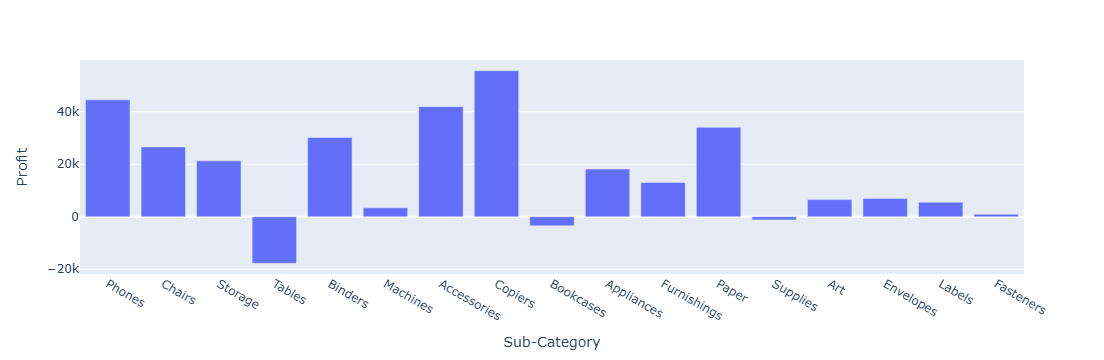

In [25]:
px.bar(subcat_profit, x = "Sub-Category", y = "Profit")

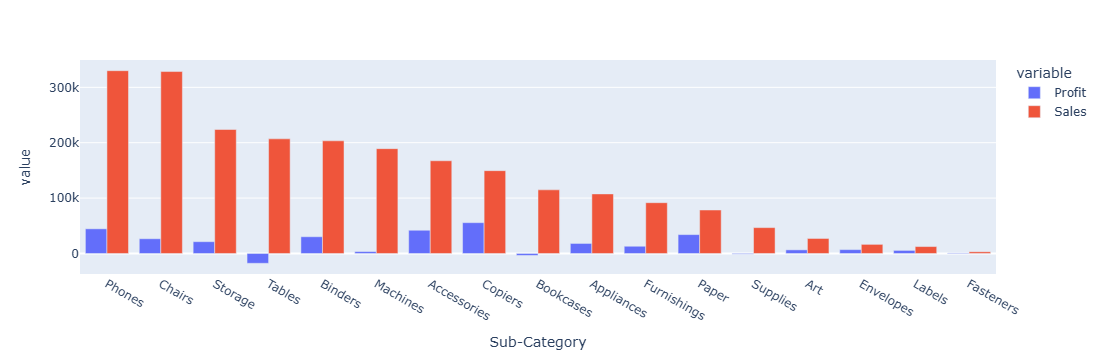

In [26]:
px.bar(subcat_profit, x = "Sub-Category", y = ["Profit", "Sales"], barmode = "group")

#### <u> CONCLUSION:

Even though Tables are second most selling product category in Furnitures and 4th most selling in all subcategories, but it gives company a loss of USD 17.725K.

Other that is giving company a loss of amount USD 3,472, followed by supplies giving loss of USD 1189.

Top 3 most profit generating category for company are :
- Copiers (USD 55.61K)
- Phones (USD 44.41K)
- Accessories(41.93K)

---

## 4. Sales and Profit Analysis by Customer Segment

In [27]:
seg_sales = data.groupby("Segment")["Sales"].sum().reset_index()
seg_sales

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


In [28]:
seg_profit = data.groupby("Segment")["Profit"].sum().reset_index()
seg_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


In [29]:
seg_data = pd.merge(seg_profit, seg_sales, how = "inner", on = "Segment")
seg_data

,Segment,Profit,Sales
0,Consumer,134119.2092,1.161401e+06
1,Corporate,91979.1340,7.061464e+05
2,Home Office,60298.6785,4.296531e+05


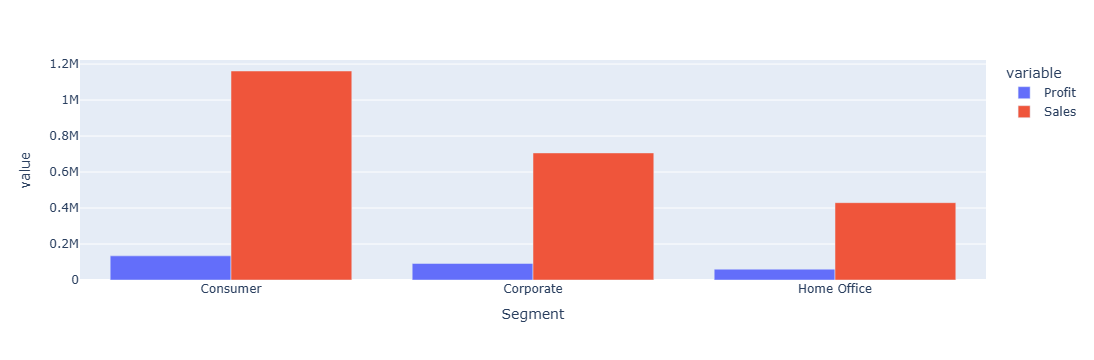

In [30]:
px.bar(seg_data, x = "Segment", y = ["Profit", "Sales"], barmode = "group")

#### <U>CONCLUSION:

In [31]:
seg_data["Sales to Profit Ratio"] = seg_data["Sales"]/seg_data["Profit"]

In [32]:
seg_data

,Segment,Profit,Sales,Sales to Profit Ratio
0,Consumer,134119.2092,1.161401e+06,8.659471
1,Corporate,91979.1340,7.061464e+05,7.677245
2,Home Office,60298.6785,4.296531e+05,7.125416


Segment providing Maximum Profit & Sales is Consumer Segment, with Sales to Profit Ratio of: 8.65947